**Telecom Customer Churn Analytics Project (EDA + Machine Learning)**

Customer Churn Analysis is an end-to-end data analytics project aimed at identifying the key factors that contribute to customer churn in a telecommunications company. The dataset contains customer demographic information, subscription details, billing information, and service usage patterns.

The project follows a complete data analytics pipeline starting from data preprocessing and exploratory data analysis (EDA) to predictive modeling. Using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn, the dataset was analyzed to uncover patterns influencing churn. A Random Forest machine learning model was also implemented to predict the likelihood of customers leaving the service.

This analysis helps organizations understand customer behavior and supports data-driven strategies to improve customer retention.

In [ ]:
# Data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_452/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


11

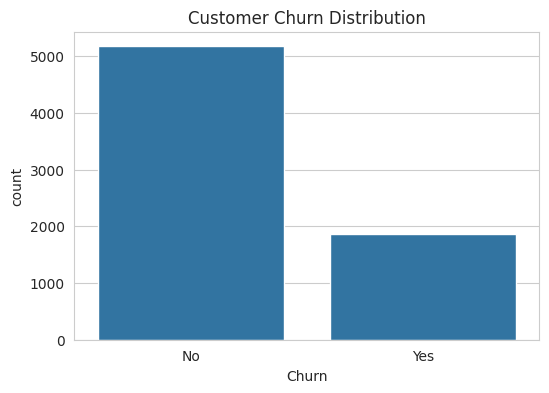

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

12.GENDER v/s CHURN

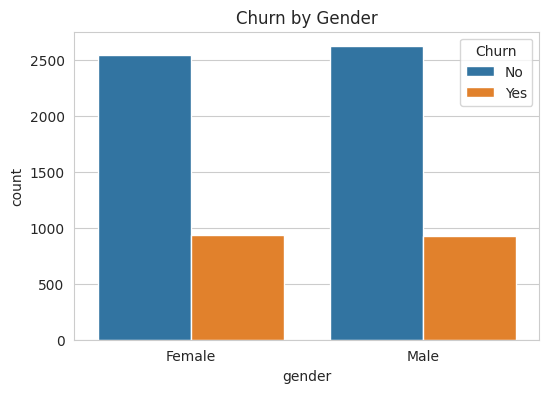

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Churn by Gender")
plt.show()

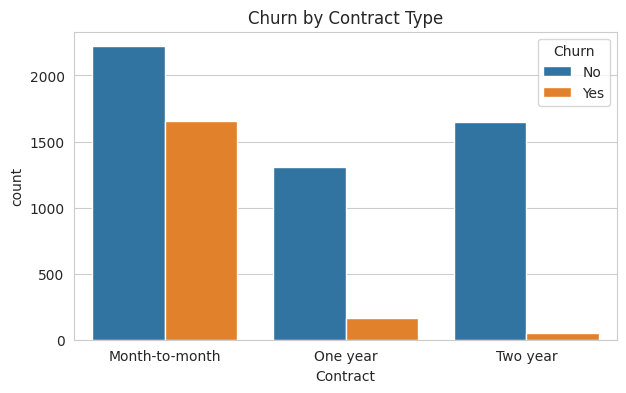

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.show()

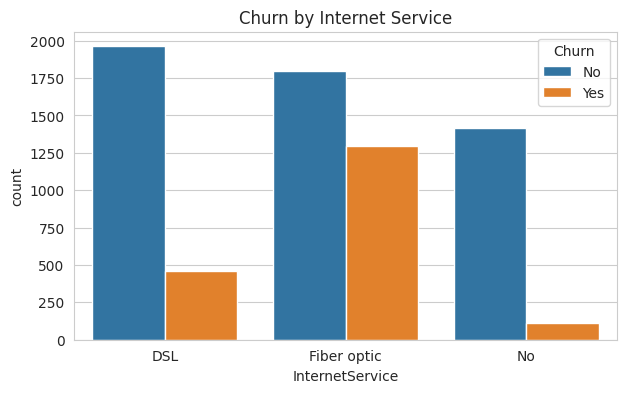

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")
plt.show()

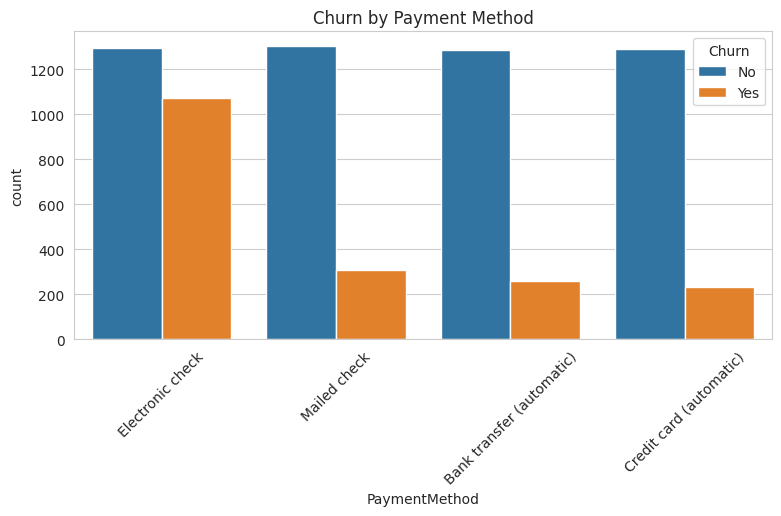

In [ ]:
plt.figure(figsize=(9,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

16.

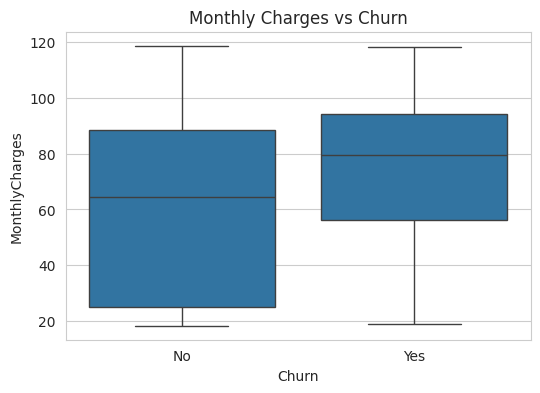

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

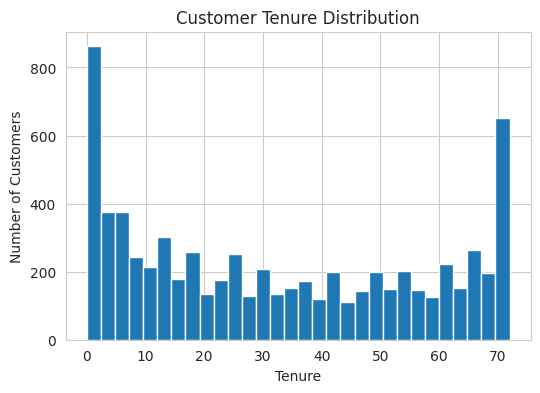

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

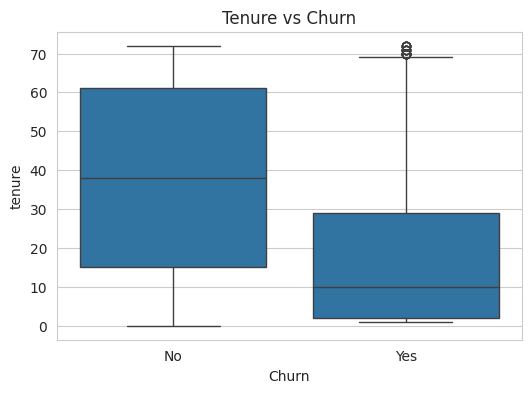

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

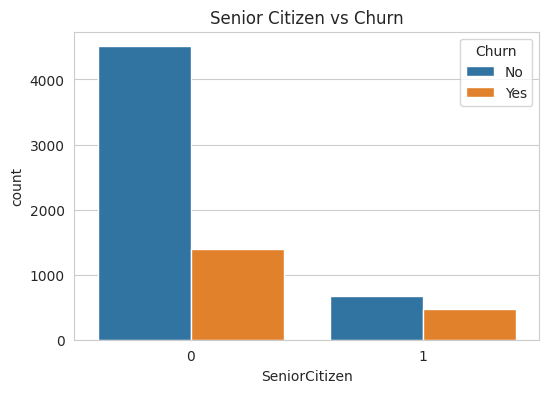

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")
plt.show()

In [ ]:
df_encoded = df.copy()

label_encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

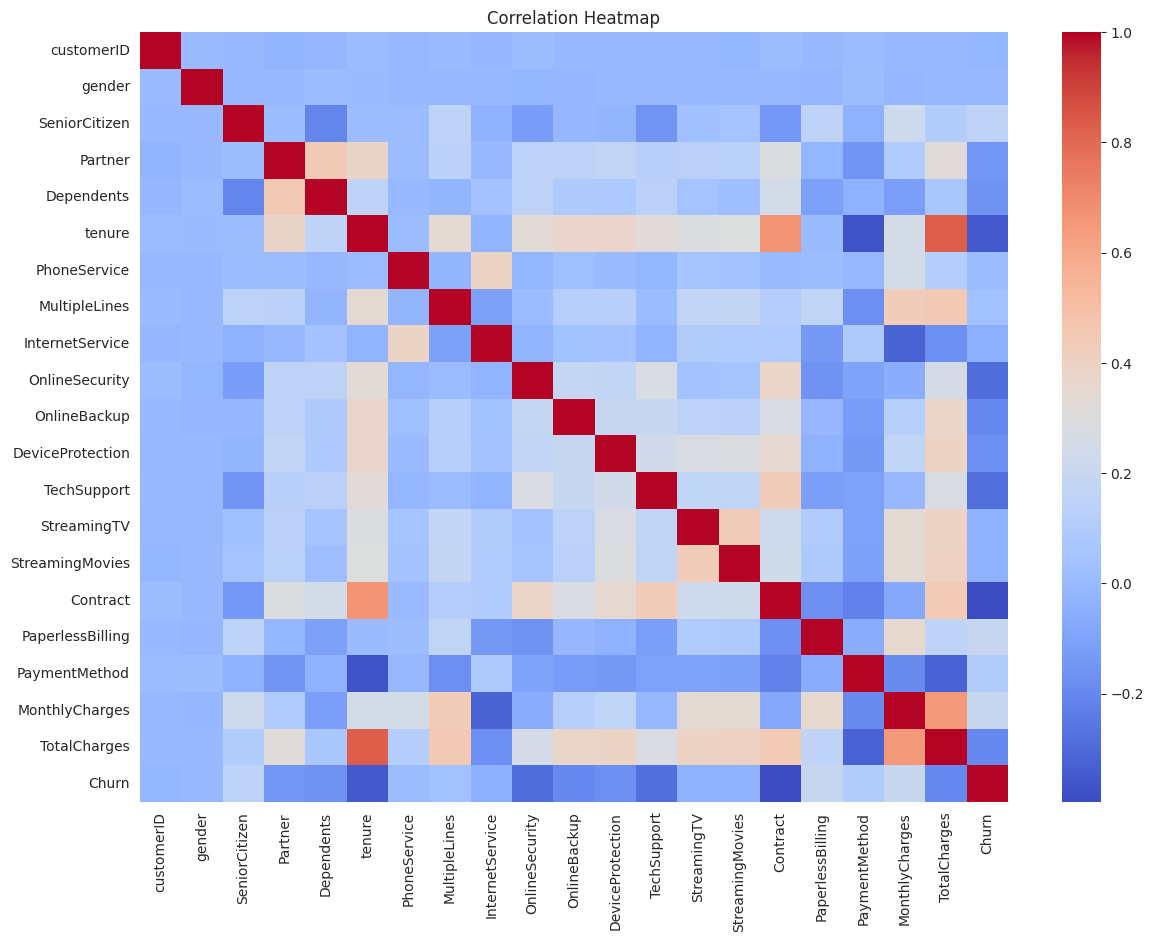

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

FEATURE SELECTION

In [ ]:
df_model = df_encoded.drop("customerID", axis=1)

In [ ]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
predictions = model.predict(X_test)

27.MODEL ACCURACY

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8026969481902059


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.69      0.47      0.56       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



CONFUSION MATRIX

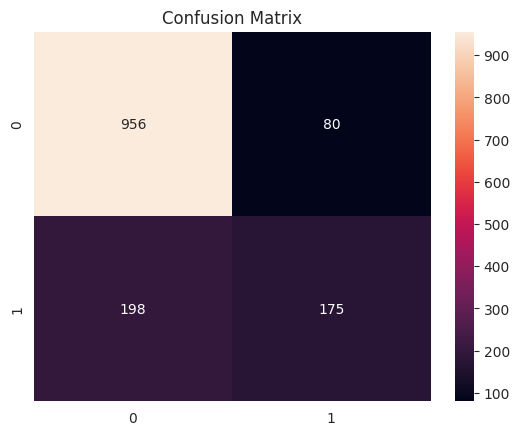

In [ ]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.show()

In [ ]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.184004
MonthlyCharges,0.179497
tenure,0.163221
Contract,0.075827
PaymentMethod,0.051204
TechSupport,0.046105
OnlineSecurity,0.040389
OnlineBackup,0.030252
gender,0.027977
PaperlessBilling,0.025978


PLOT FEATURE IMPORTATNCE

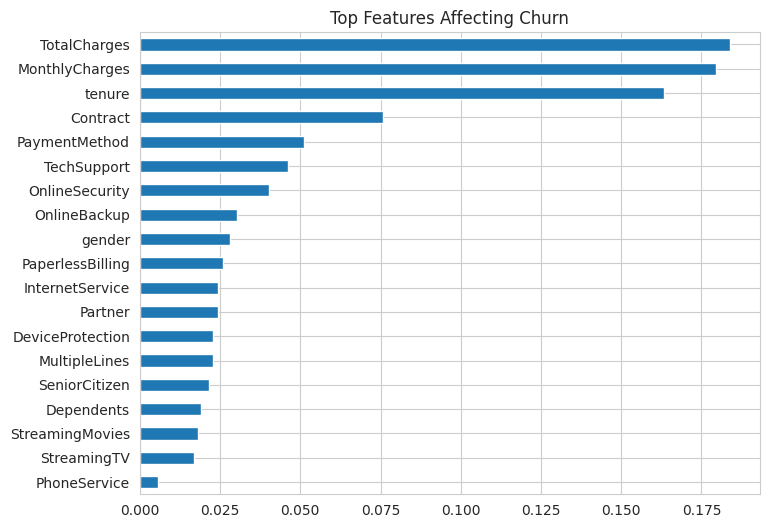

In [ ]:
feature_importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Top Features Affecting Churn")
plt.show()

Conclusion

The analysis revealed several important factors influencing customer churn. Customers with month-to-month contracts and higher monthly charges were more likely to leave the service. Additionally, customers with shorter tenure showed higher churn rates compared to long-term customers. Payment methods such as electronic checks were also associated with higher churn levels.

The predictive model built using the Random Forest algorithm achieved a good accuracy score and helped identify the most influential features contributing to churn. These insights can help businesses implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss caused by customer attrition.

Overall, this project demonstrates an end-to-end data analytics workflow including data cleaning, exploratory analysis, visualization and predictive modeling to generate actionable business insights.